In [296]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

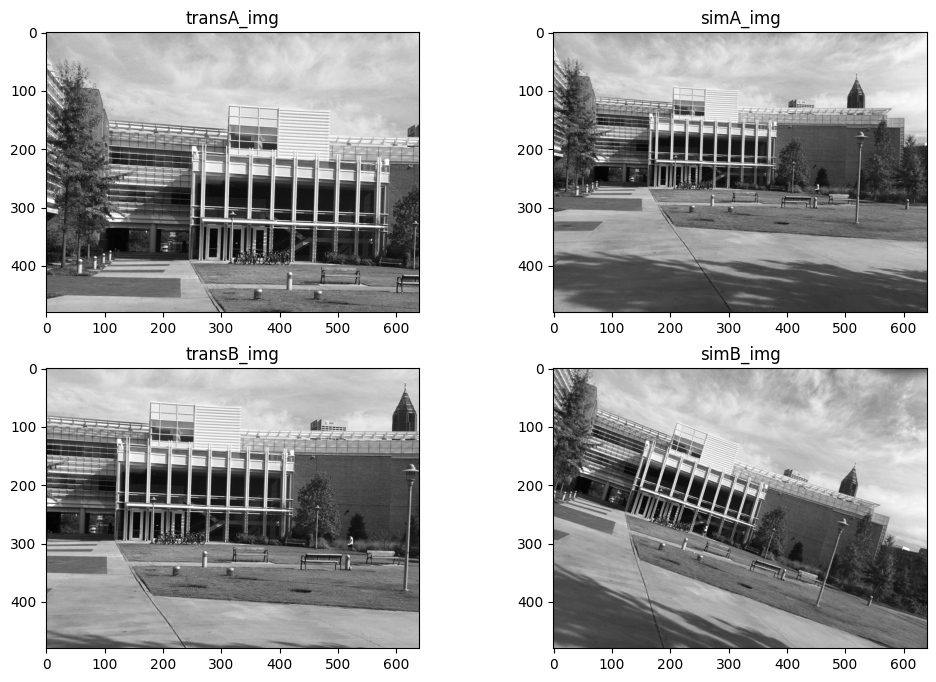

In [297]:
transA_img = cv2.imread('transA.jpg', cv2.IMREAD_GRAYSCALE)
simA_img = cv2.imread('simA.jpg', cv2.IMREAD_GRAYSCALE)
transB_img = cv2.imread('transB.jpg', cv2.IMREAD_GRAYSCALE)
simB_img = cv2.imread('simB.jpg', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.title('transA_img')
plt.imshow(transA_img, cmap='gray')
plt.subplot(2, 2, 2)
plt.title('simA_img')
plt.imshow(simA_img, cmap='gray')
plt.subplot(2, 2, 3)
plt.title('transB_img')
plt.imshow(transB_img, cmap='gray')
plt.subplot(2, 2, 4)
plt.title('simB_img')
plt.imshow(simB_img, cmap='gray')
plt.show()


## Image Gradients

In [298]:
def img_gradients(img):
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return sobel_x, sobel_y

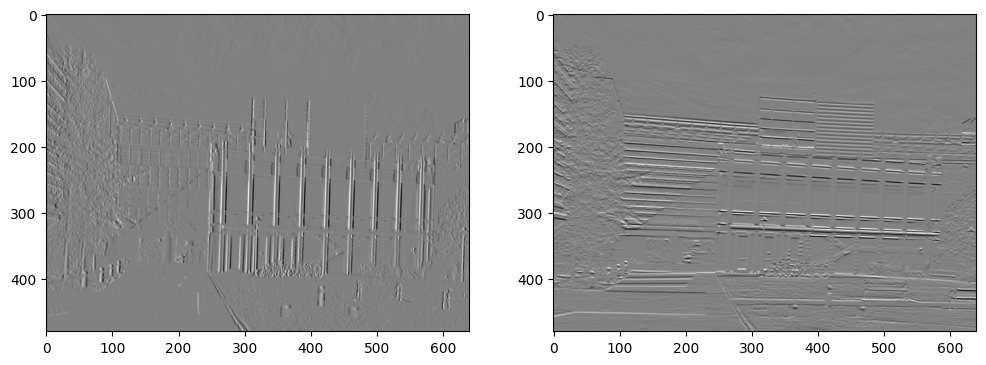

In [299]:
gradient_x, gradient_y = img_gradients(transA_img)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(gradient_x, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(gradient_y, cmap='gray')
plt.show()

## Harris Corners

In [300]:
def compute_R(I_x, I_y, window_size=5, alpha=0.04, sigma=1):
    gaussian_kernel = cv2.getGaussianKernel(window_size, sigma)
    gaussian_kernel = gaussian_kernel @ gaussian_kernel.T
    I_x2 = I_x ** 2
    I_y2 = I_y ** 2
    S_xx = cv2.filter2D(I_x2, ddepth=-1, kernel=gaussian_kernel)
    S_yy = cv2.filter2D(I_y2, ddepth=-1, kernel=gaussian_kernel)
    S_xy = cv2.filter2D(I_x * I_y, ddepth=-1, kernel=gaussian_kernel)
    det_M = S_xx * S_yy - S_xy ** 2
    trace_M = S_xx + S_yy
    return det_M - alpha * trace_M ** 2

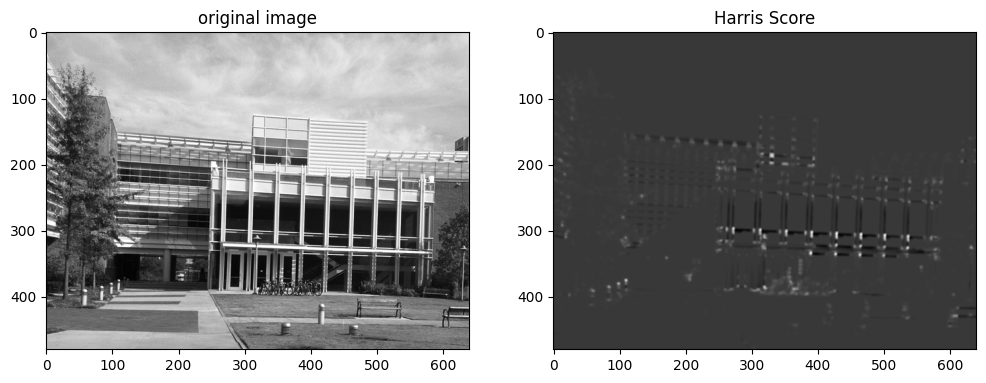

In [301]:
R = compute_R(gradient_x, gradient_y, window_size=7, sigma=2)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('original image')
plt.imshow(transA_img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Harris Score')
plt.imshow(R, cmap='gray')
plt.show()

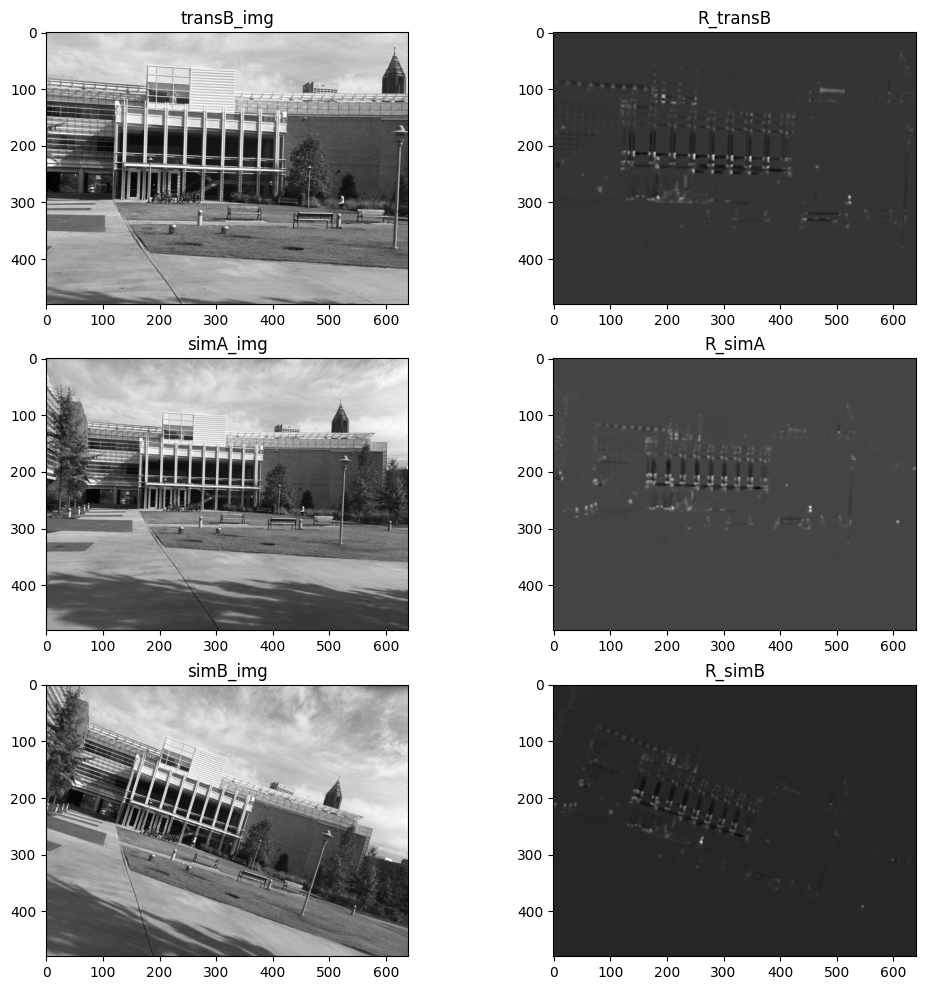

In [302]:
transB_gradient_x, transB_gradient_y = img_gradients(transB_img)
simA_gradient_x, simA_gradient_y = img_gradients(simA_img)
simB_gradient_x, simB_gradient_y = img_gradients(simB_img)
R_transB = compute_R(transB_gradient_x, transB_gradient_y, window_size=7, sigma=2)
R_simA = compute_R(simA_gradient_x, simA_gradient_y, window_size=7, sigma=2)
R_simB = compute_R(simB_gradient_x, simB_gradient_y, window_size=7, sigma=2)
plt.figure(figsize=(12, 12))
plt.subplot(3, 2, 1)
plt.title('transB_img')
plt.imshow(transB_img, cmap='gray')
plt.subplot(3, 2, 2)
plt.title('R_transB')
plt.imshow(R_transB, cmap='gray')

plt.subplot(3, 2, 3)
plt.title('simA_img')
plt.imshow(simA_img, cmap='gray')
plt.subplot(3, 2, 4)
plt.title('R_simA')
plt.imshow(R_simA, cmap='gray')

plt.subplot(3, 2, 5)
plt.title('simB_img')
plt.imshow(simB_img, cmap='gray')
plt.subplot(3, 2, 6)
plt.title('R_simB')
plt.imshow(R_simB, cmap='gray')

plt.show()

In [303]:
def threshold_R(R, pecentile=90):
    non_zero_R = R[R > 0]
    threshold = np.percentile(non_zero_R, pecentile)
    return R > threshold

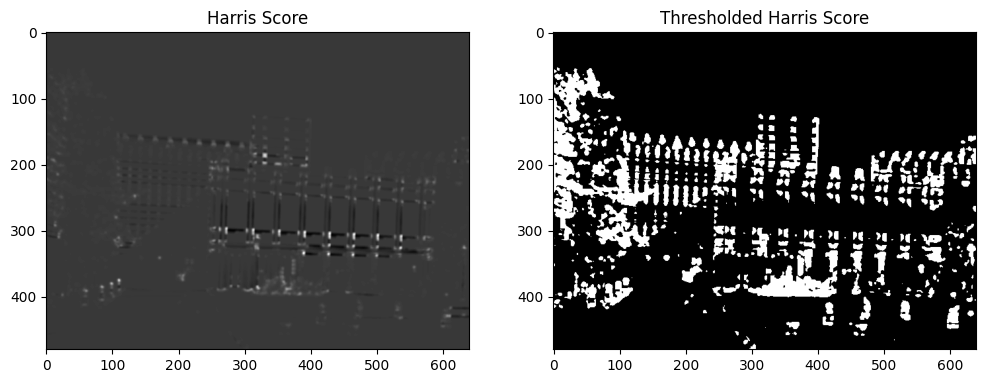

In [304]:
transA_R_threshold = threshold_R(R, 80)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Harris Score')
plt.imshow(R, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Thresholded Harris Score')
plt.imshow(transA_R_threshold, cmap='gray')
plt.show()

In [305]:
def non_max_suppression(R, window_size=20, percentile=80):
    non_zero_R = R[R > 0]
    threshold = np.percentile(non_zero_R, percentile)
    maximum_filtered = cv2.dilate(R, np.ones((window_size, window_size)))
    minimum_filtered = cv2.erode(R, np.ones((window_size, window_size)))
    R_filtered = (R == maximum_filtered) & (R != minimum_filtered) & (R > threshold)
    return R_filtered

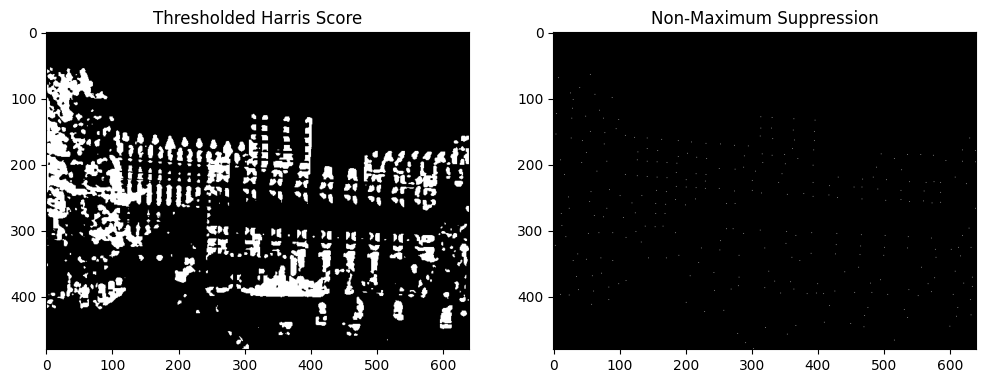

In [306]:
nms_transA_R = non_max_suppression(R)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Thresholded Harris Score')
plt.imshow(transA_R_threshold, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Non-Maximum Suppression')
plt.imshow(nms_transA_R, cmap='gray')
plt.show()

In [307]:
def display_corners_on_image(img, corners, color=(0, 255, 0)):
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for corner in corners:
        cv2.circle(img, tuple([corner[-1], corner[0]]), 3, color, -1)
    return img

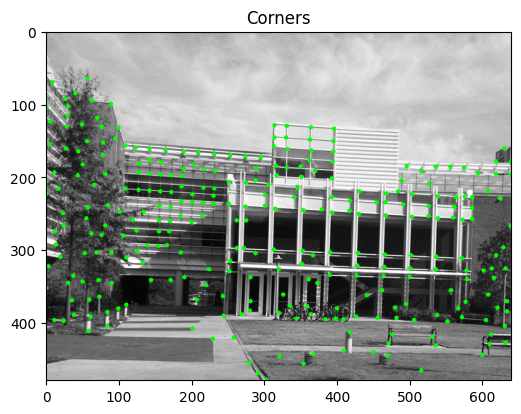

In [308]:
corner_img = display_corners_on_image(transA_img, np.argwhere(nms_transA_R))
plt.figure(figsize=(6, 6))
plt.title('Corners')
plt.imshow(corner_img)
plt.show()

## SIFT Descriptors

In [309]:
def compute_corners_angles(I_x, I_y, corners):
    gradient_angles = np.arctan2(I_y, I_x)
    corner_angles = gradient_angles[corners[:, 0], corners[:, 1]]
    return corner_angles

def draw_corner_angles(img, corners, angles):
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for corner, angle in zip(corners, angles):
        end_point = (corner + 20 * np.array([np.cos(angle), np.sin(angle)])).astype(np.int32)
        cv2.line(img, tuple([corner[-1], corner[0]]), tuple([end_point[-1], end_point[0]]), (0, 255, 0), 2)
    return img

In [310]:
corners_indices = np.argwhere(nms_transA_R)
corner_angles = compute_corners_angles(gradient_x, gradient_y, corners_indices)
corner_angles_img = draw_corner_angles(transA_img, corners_indices, corner_angles)

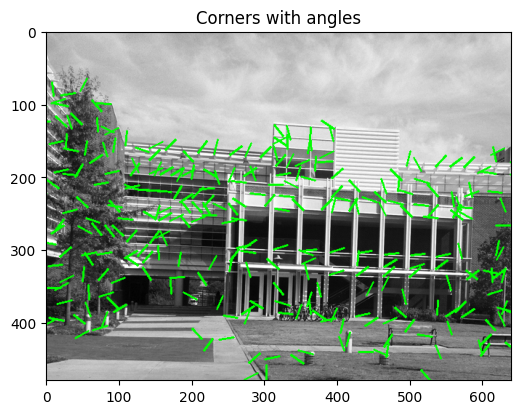

In [311]:
plt.figure(figsize=(6, 6))
plt.title('Corners with angles')
plt.imshow(corner_angles_img)
plt.show()

In [312]:
def load_keypoints(keypoints, angles):
    keypoints_sift = [cv2.KeyPoint(x=keypoint[1], y=keypoint[0], size=20, angle=np.degrees(
        angle)) for keypoint, angle in zip(keypoints, angles)]
    return keypoints_sift

In [313]:
sift = cv2.SIFT_create()
keypoints = load_keypoints(corners_indices.astype(float), corner_angles)
transA_points, transA_descriptors = sift.compute(transA_img, keypoints)

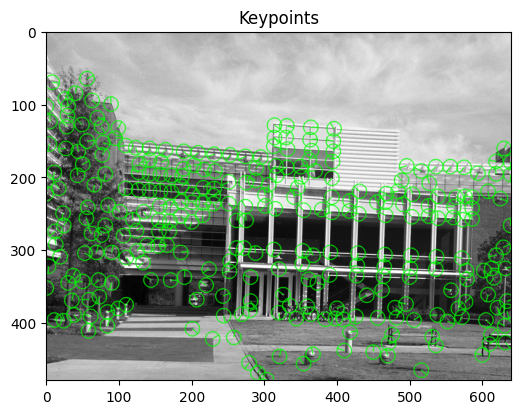

In [314]:
keypoints_img = cv2.drawKeypoints(transA_img, keypoints, None, color=(
    0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(6, 6))
plt.title('Keypoints')
plt.imshow(keypoints_img)
plt.show()

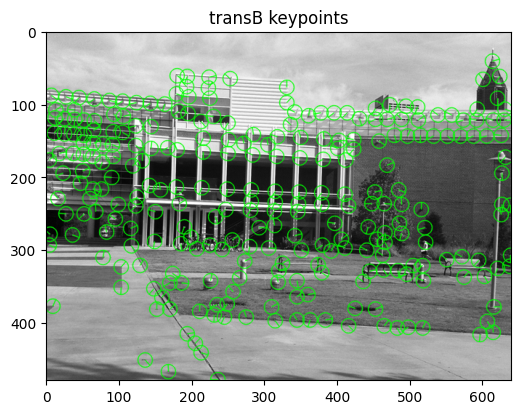

In [315]:
nms_transB_R = non_max_suppression(R_transB)
keypoints = load_keypoints(np.argwhere(nms_transB_R).astype(
    float), compute_corners_angles(transB_gradient_x, transB_gradient_y, np.argwhere(nms_transB_R)))
sift = cv2.SIFT_create()
transB_points, transB_descriptors = sift.compute(transB_img, keypoints)
transB_keypoints_img = cv2.drawKeypoints(transB_img, keypoints, None, color=(
    0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(6, 6))
plt.title('transB keypoints')
plt.imshow(transB_keypoints_img)
plt.show()

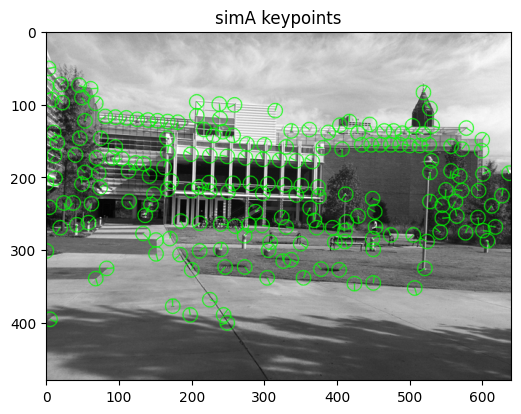

In [316]:
nms_simA_R = non_max_suppression(R_simA)
keypoints = load_keypoints(np.argwhere(nms_simA_R).astype(
    float), compute_corners_angles(simA_gradient_x, simA_gradient_y, np.argwhere(nms_simA_R)))
sift = cv2.SIFT_create()
simA_points, simA_descriptors = sift.compute(simA_img, keypoints)
simA_keypoints_img = cv2.drawKeypoints(simA_img, keypoints, None, color=(
    0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(6, 6))
plt.title('simA keypoints')
plt.imshow(simA_keypoints_img)
plt.show()

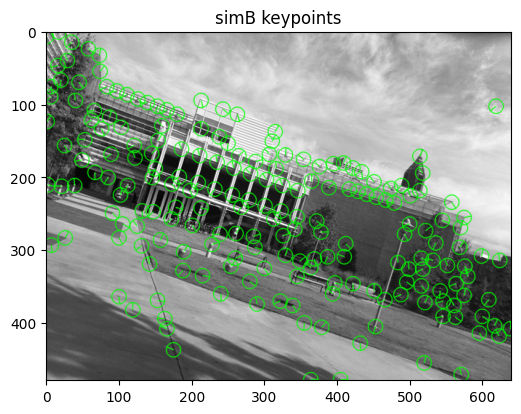

In [317]:
nms_simB_R = non_max_suppression(R_simB)
keypoints = load_keypoints(np.argwhere(nms_simB_R).astype(
    float), compute_corners_angles(simB_gradient_x, simB_gradient_y, np.argwhere(nms_simB_R)))
sift = cv2.SIFT_create()
simB_points, simB_descriptors = sift.compute(simB_img, keypoints)
simB_keypoints_img = cv2.drawKeypoints(simB_img, keypoints, None, color=(
    0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(6, 6))
plt.title('simB keypoints')
plt.imshow(simB_keypoints_img)
plt.show()

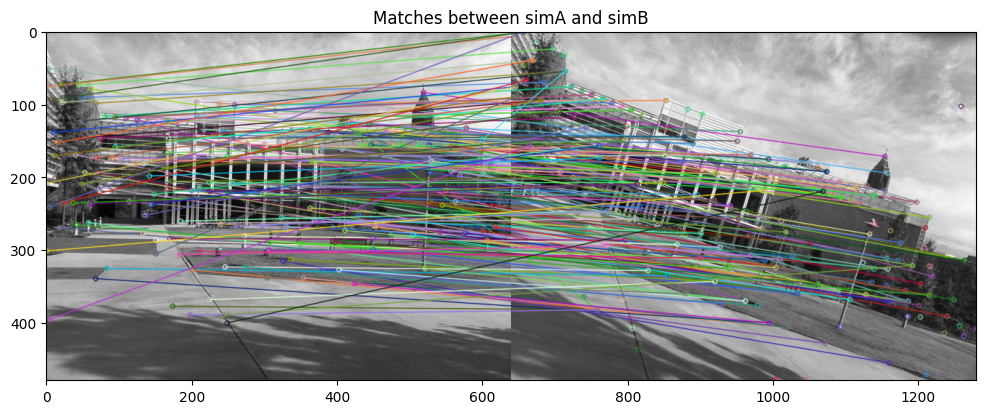

In [318]:
bfm = cv2.BFMatcher()
matches = bfm.match(simA_descriptors, simB_descriptors)
matches_img = cv2.drawMatches(
    simA_img, simA_points, simB_img, simB_points, matches, None)
plt.figure(figsize=(12, 6))
plt.title('Matches between simA and simB')
plt.imshow(matches_img)
plt.show()

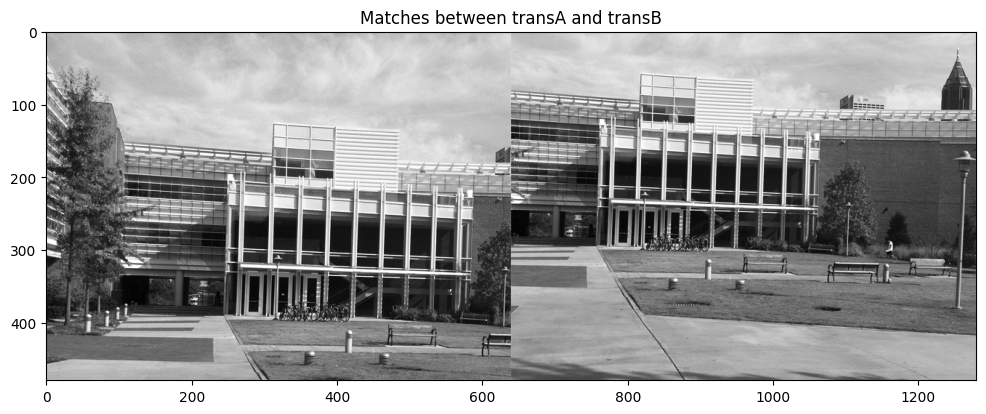

In [319]:
match_img = np.zeros((transA_img.shape[0], transA_img.shape[1] * 2))
match_img[:, :transA_img.shape[1]] = transA_img
match_img[:, transA_img.shape[1]:] = transB_img
plt.figure(figsize=(12, 6))
plt.title('Matches between transA and transB')  
plt.imshow(match_img, cmap='gray')
plt.show()

In [320]:
def draw_match_points(combined_img, matches, left_img_keypoints, right_img_keypoints):
    h, w = combined_img.shape
    matched_img = combined_img.copy()
    for match in matches: 
        point1 = tuple(map(int, left_img_keypoints[match.queryIdx].pt))
        point2 = tuple(map(int, right_img_keypoints[match.trainIdx].pt))
        point2 = (point2[0] + w // 2, point2[1])
        cv2.circle(matched_img, point1, 3, (0, 255, 0), 2)
        cv2.circle(matched_img, point2, 3, (0, 255, 0), 2)
        cv2.line(matched_img, point1, point2, (0, 255, 0), 2)
    return matched_img

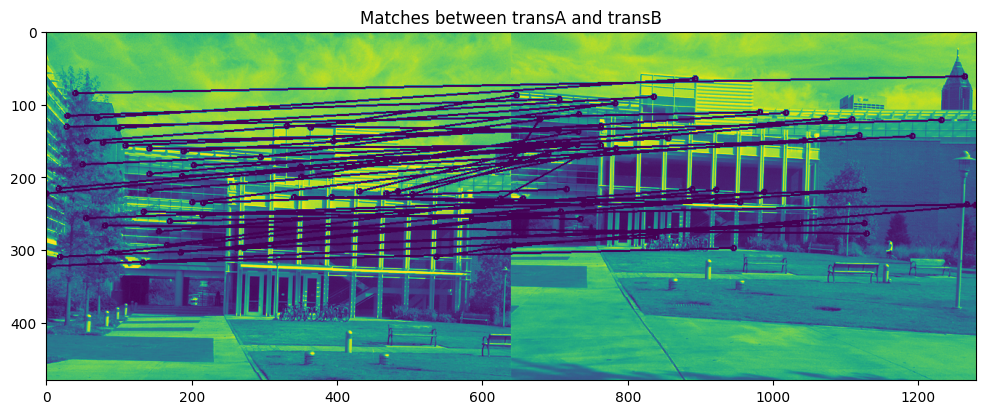

In [321]:
trans_matches = bfm.match(transA_descriptors, transB_descriptors)
sorted_matches = sorted(matches, key=lambda x: x.distance)
matched_img = draw_match_points(match_img, sorted_matches[:50], transA_points, transB_points)
plt.figure(figsize=(12, 6))
plt.title('Matches between transA and transB')
plt.imshow(matched_img)
plt.show()

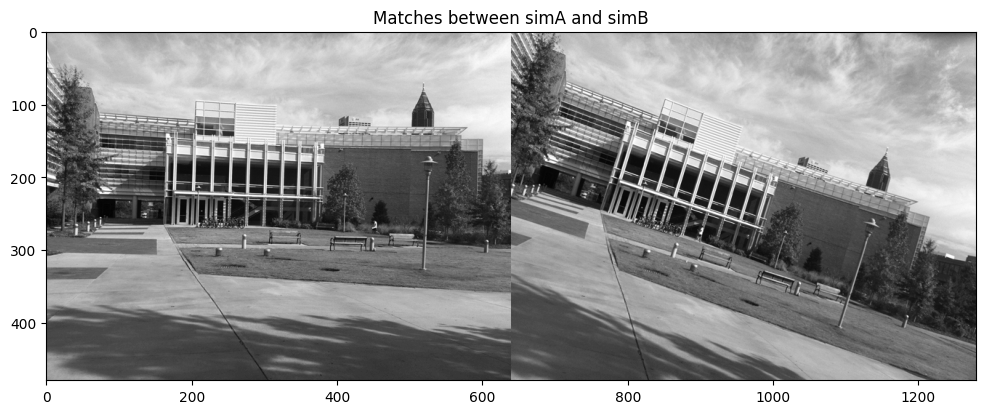

In [322]:
sim_matched_img = np.zeros((simA_img.shape[0], simA_img.shape[1] * 2))
sim_matched_img[:, :simA_img.shape[1]] = simA_img
sim_matched_img[:, simA_img.shape[1]:] = simB_img
plt.figure(figsize=(12, 6))
plt.title('Matches between simA and simB')
plt.imshow(sim_matched_img, cmap='gray')
plt.show()

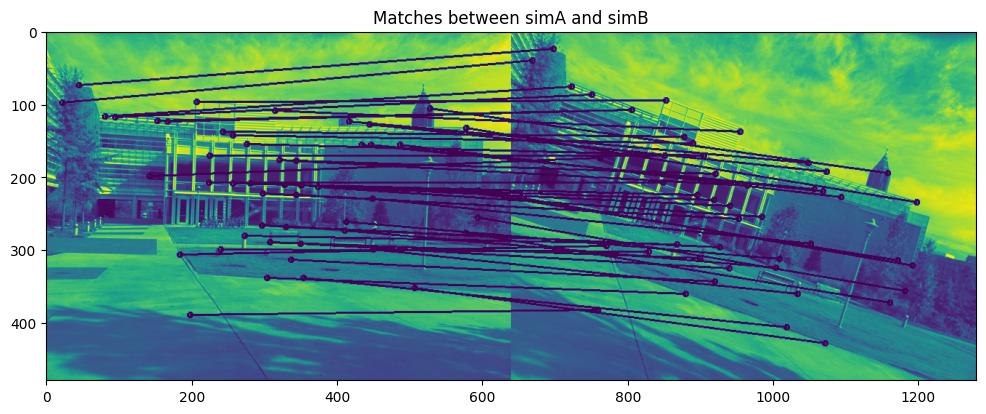

In [323]:
sim_matches = bfm.match(simA_descriptors, simB_descriptors)
sorted_sim_matches = sorted(sim_matches, key=lambda x: x.distance)
sim_matched_img = draw_match_points(
    sim_matched_img, sorted_sim_matches[:50], simA_points, simB_points)
plt.figure(figsize=(12, 6))
plt.title('Matches between simA and simB')
plt.imshow(sim_matched_img)
plt.show()

## RANSAC

In [328]:
np.random.seed(42)
def find_best_match_for_translation(matches, left_keypoints, right_keypoints, tolerance=5, iterations=10000):
    best_translation = None
    best_inliers = []
    for _ in range(iterations):
        match = np.random.choice(matches)
        point1 = np.array(left_keypoints[match.queryIdx].pt)
        point2 = np.array(right_keypoints[match.trainIdx].pt)
        translation = point2 - point1
        consensus_set = []
        for match in matches:
            point1 = np.array(left_keypoints[match.queryIdx].pt)
            point2 = np.array(right_keypoints[match.trainIdx].pt)
            if np.linalg.norm(point2 - point1 - translation) < tolerance:
                consensus_set.append(match)
        if len(consensus_set) > len(best_inliers):
            best_translation = translation
            best_inliers = consensus_set
    return best_translation, best_inliers

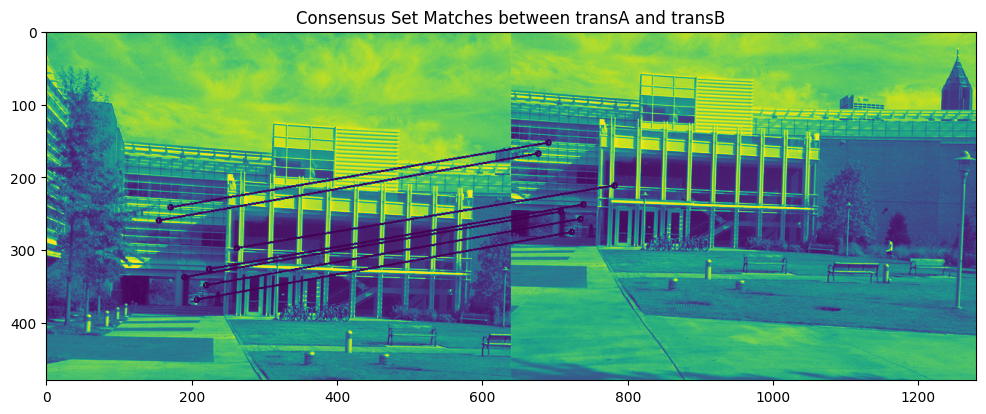

In [329]:
best_translation, best_inliers = find_best_match_for_translation(
    trans_matches, transA_points, transB_points)
consensus_img = draw_match_points(match_img, best_inliers, transA_points, transB_points)
plt.figure(figsize=(12, 6))
plt.title('Consensus Set Matches between transA and transB')
plt.imshow(consensus_img)
plt.show()

In [326]:
def find_best_match_for_similarity_transformation(matches, left_keypoints, right_keypoints, tolerance=1, iterations=10000):
    best_transformation = None
    best_inliers = []
    for _ in range(iterations):
        match1, match2 = np.random.choice(matches, 2)
        point1 = np.array(left_keypoints[match1.queryIdx].pt)
        point2 = np.array(right_keypoints[match1.trainIdx].pt)
        point3 = np.array(left_keypoints[match2.queryIdx].pt)
        point4 = np.array(right_keypoints[match2.trainIdx].pt)
        transformation = cv2.estimateAffinePartial2D(
            np.array([point1, point3]), np.array([point2, point4]))
        if transformation is None:
            continue
        consensus_set = []
        for match in matches:
            point1 = np.array(left_keypoints[match.queryIdx].pt)
            point2 = np.array(right_keypoints[match.trainIdx].pt)
            point1_transformed = cv2.transform(np.array([[point1]]), transformation[0])[0][0]
            if np.linalg.norm(point2 - point1_transformed) < tolerance:
                consensus_set.append(match)
        if len(consensus_set) > len(best_inliers):
            best_transformation = transformation
            best_inliers = consensus_set
    return best_transformation, best_inliers

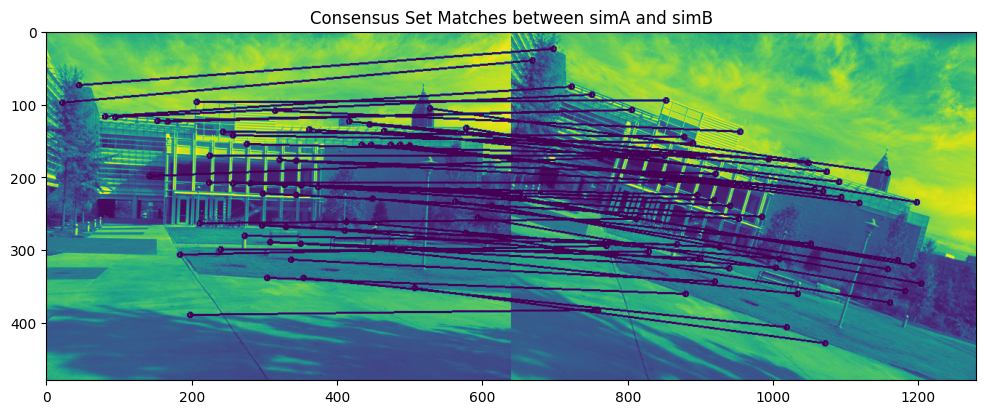

In [327]:
best_transformation, best_inliers = find_best_match_for_similarity_transformation(
    sim_matches, simA_points, simB_points)
consensus_img = draw_match_points(sim_matched_img, best_inliers, simA_points, simB_points)
plt.figure(figsize=(12, 6))
plt.title('Consensus Set Matches between simA and simB')
plt.imshow(consensus_img)
plt.show()